In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv(
    "../data/cleaned/supply_chain_clean.csv"
)

print(df.shape)

(180519, 45)


In [3]:
late_counts = df["late_delivery_risk"].value_counts()

print(late_counts)

late_percentage = (
    df["late_delivery_risk"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print("\nPercentage:")
print(late_percentage)

late_delivery_risk
1    98977
0    81542
Name: count, dtype: int64

Percentage:
late_delivery_risk
1    54.83
0    45.17
Name: proportion, dtype: float64


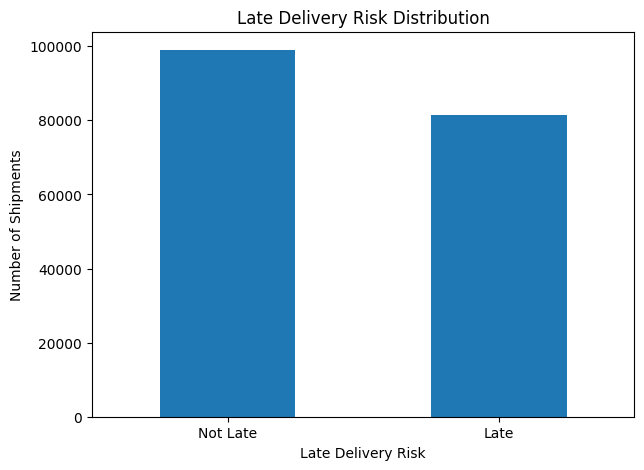

In [4]:
late_counts.plot(
    kind="bar",
    figsize=(7, 5)
)

plt.title("Late Delivery Risk Distribution")
plt.xlabel("Late Delivery Risk")
plt.ylabel("Number of Shipments")
plt.xticks(
    ticks=[0, 1],
    labels=["Not Late", "Late"],
    rotation=0
)
plt.show()

In [5]:
shipping_delay = (
    df.groupby("shipping_mode")["late_delivery_risk"]
    .agg(["count", "sum"])
)

shipping_delay["delay_rate"] = (
    shipping_delay["sum"] /
    shipping_delay["count"] * 100
)

shipping_delay = shipping_delay.sort_values(
    "delay_rate",
    ascending=False
)

shipping_delay

,count,sum,delay_rate
shipping_mode,,,
First Class,27814,26513,95.322499
Second Class,35216,26987,76.632781
Same Day,9737,4454,45.743042
Standard Class,107752,41023,38.071683


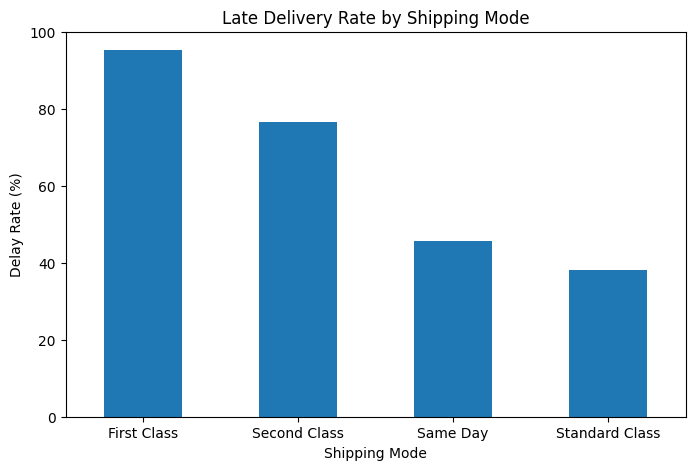

In [6]:
shipping_delay["delay_rate"].plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Late Delivery Rate by Shipping Mode")
plt.xlabel("Shipping Mode")
plt.ylabel("Delay Rate (%)")
plt.xticks(rotation=0)
plt.show()

In [7]:
market_delay = (
    df.groupby("market")["late_delivery_risk"]
    .agg(["count", "sum"])
)

market_delay["delay_rate"] = (
    market_delay["sum"] /
    market_delay["count"] * 100
)

market_delay = market_delay.sort_values(
    "delay_rate",
    ascending=False
)

market_delay

,count,sum,delay_rate
market,,,
Europe,50252,27743,55.207753
Pacific Asia,41260,22712,55.046049
USCA,25799,14138,54.800574
Africa,11614,6340,54.589289
LATAM,51594,28044,54.355158


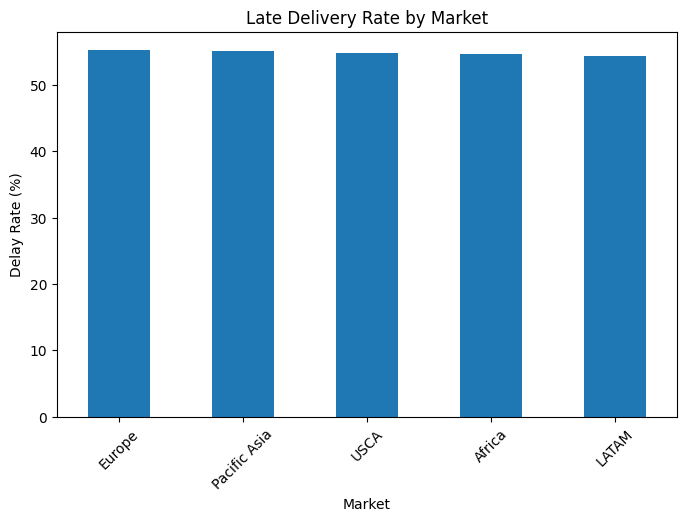

In [8]:
market_delay["delay_rate"].plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Late Delivery Rate by Market")
plt.xlabel("Market")
plt.ylabel("Delay Rate (%)")
plt.xticks(rotation=45)
plt.show()

In [9]:
region_delay = (
    df.groupby("order_region")["late_delivery_risk"]
    .agg(["count", "sum"])
)

region_delay["delay_rate"] = (
    region_delay["sum"] /
    region_delay["count"] * 100
)

region_delay = region_delay.sort_values(
    "delay_rate",
    ascending=False
)

region_delay

,count,sum,delay_rate
order_region,,,
Central Africa,1677,972,57.960644
South Asia,7731,4350,56.266977
East Africa,1852,1036,55.939525
Western Europe,27109,15140,55.848611
South of USA,4045,2256,55.772559
Eastern Europe,3920,2182,55.663265
East of USA,6915,3849,55.661605
Southeast Asia,9539,5297,55.529930
Central Asia,553,306,55.334539


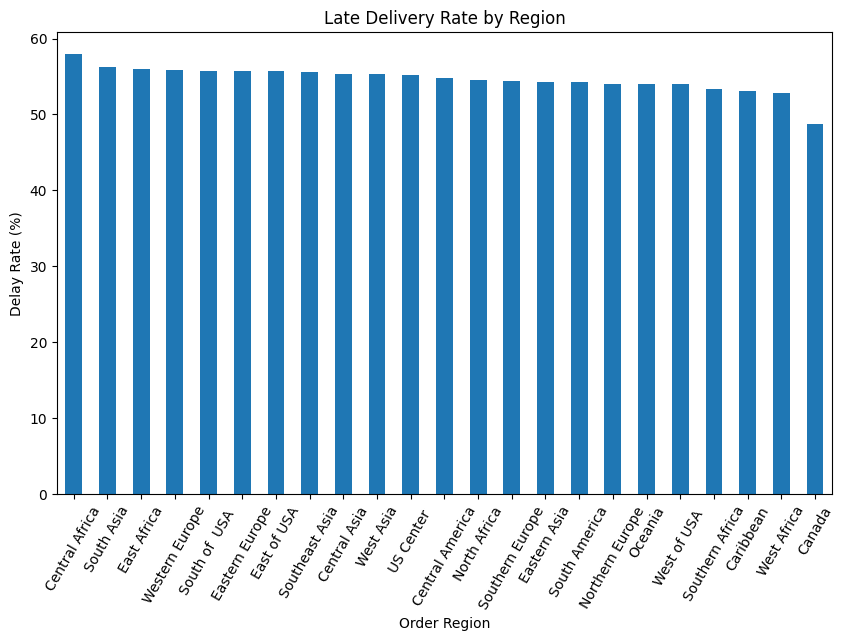

In [10]:
region_delay["delay_rate"].plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Late Delivery Rate by Region")
plt.xlabel("Order Region")
plt.ylabel("Delay Rate (%)")
plt.xticks(rotation=60)
plt.show()

In [14]:
category_delay = (
    df.groupby("category_name")["late_delivery_risk"]
    .agg(["count", "sum"])
)

category_delay["delay_rate"] = (
    category_delay["sum"] /
    category_delay["count"] * 100
)

category_delay = category_delay.sort_values(
    "delay_rate",
    ascending=False
)

category_delay

,count,sum,delay_rate
category_name,,,
Golf Bags & Carts,61,42,68.852459
Lacrosse,343,206,60.058309
Pet Supplies,492,290,58.943089
Cameras,592,344,58.108108
Strength Training,111,64,57.657658
As Seen on TV!,68,39,57.352941
Music,434,248,57.142857
Accessories,1780,1014,56.966292
Fitness Accessories,309,176,56.957929


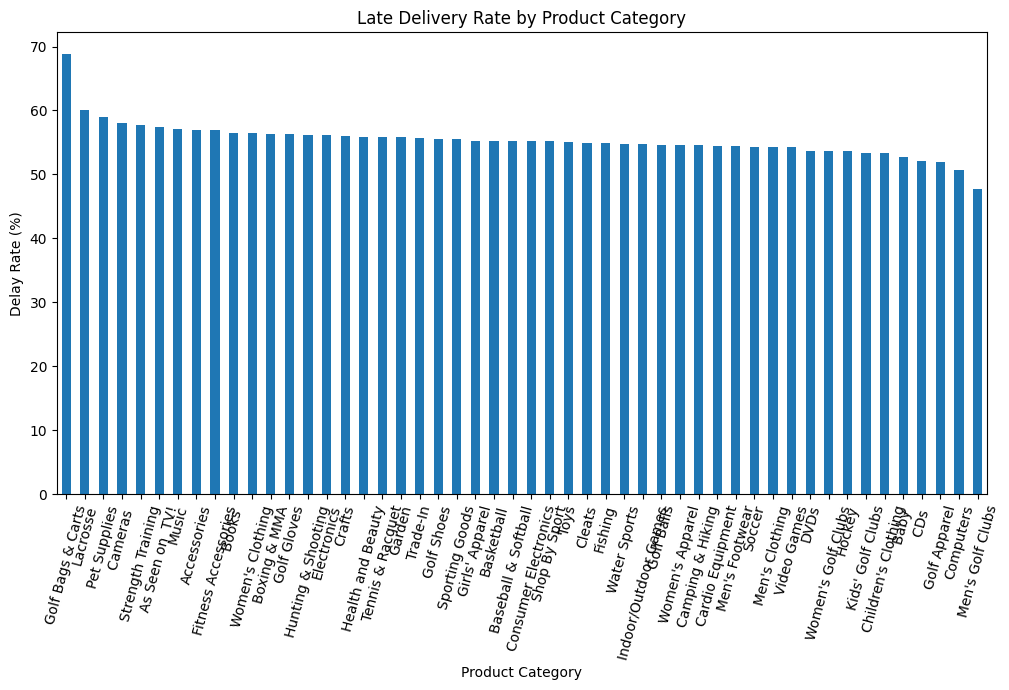

In [15]:
category_delay["delay_rate"].plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Late Delivery Rate by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Delay Rate (%)")
plt.xticks(rotation=75)
plt.show()

In [16]:
segment_delay = (
    df.groupby("customer_segment")["late_delivery_risk"]
    .agg(["count", "sum"])
)

segment_delay["delay_rate"] = (
    segment_delay["sum"] /
    segment_delay["count"] * 100
)

segment_delay.sort_values(
    "delay_rate",
    ascending=False
)

,count,sum,delay_rate
customer_segment,,,
Home Office,32226,17747,55.070440
Consumer,93504,51248,54.808350
Corporate,54789,29982,54.722663


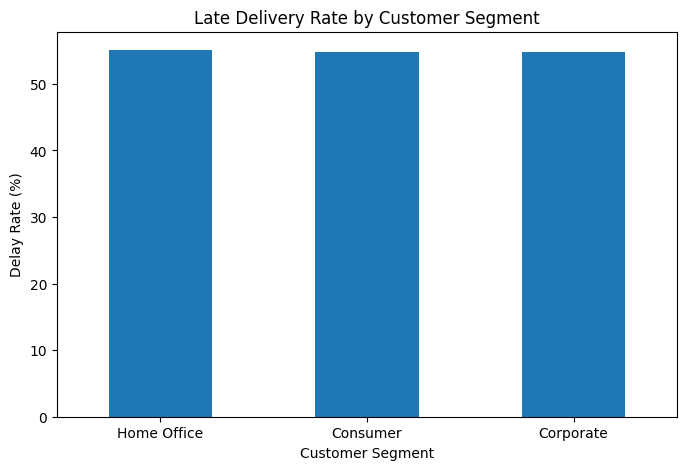

In [17]:
segment_delay["delay_rate"].sort_values(
    ascending=False
).plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Late Delivery Rate by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Delay Rate (%)")
plt.xticks(rotation=0)
plt.show()

In [19]:
df["shipping_delay_days"] = (
    df["days_for_shipping_real"] -
    df["days_for_shipment_scheduled"]
)

In [20]:
df["shipping_delay_days"].describe()

count    180519.000000
mean          0.565807
std           1.490966
min          -2.000000
25%           0.000000
50%           1.000000
75%           1.000000
max           4.000000
Name: shipping_delay_days, dtype: float64

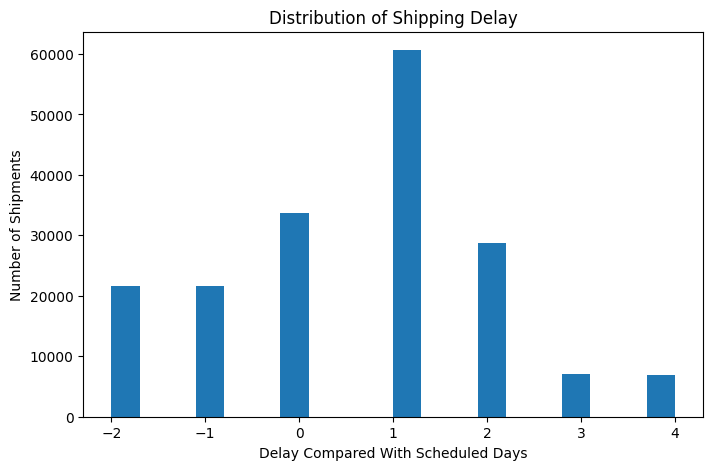

In [21]:
df["shipping_delay_days"].plot(
    kind="hist",
    bins=20,
    figsize=(8, 5)
)

plt.title("Distribution of Shipping Delay")
plt.xlabel("Delay Compared With Scheduled Days")
plt.ylabel("Number of Shipments")
plt.show()

In [22]:
scheduled_analysis = (
    df.groupby("late_delivery_risk")
    ["days_for_shipment_scheduled"]
    .agg(["count", "mean", "median", "min", "max"])
)

scheduled_analysis

,count,mean,median,min,max
late_delivery_risk,,,,,
0,81542,3.491146,4.0,0,4
1,98977,2.471069,2.0,0,4


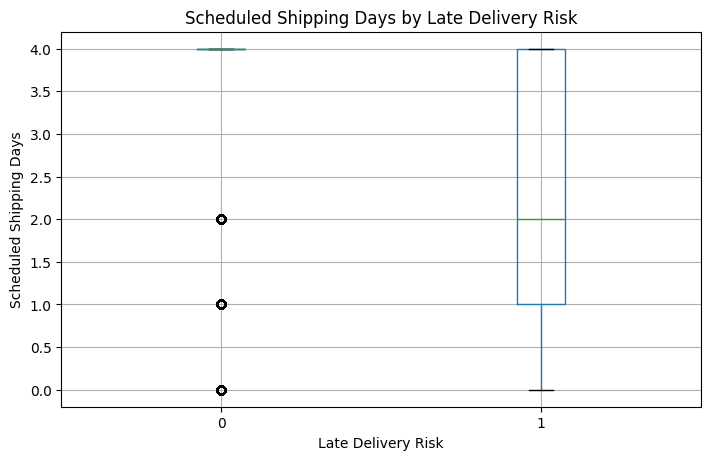

In [23]:
df.boxplot(
    column="days_for_shipment_scheduled",
    by="late_delivery_risk",
    figsize=(8, 5)
)

plt.title("Scheduled Shipping Days by Late Delivery Risk")
plt.suptitle("")
plt.xlabel("Late Delivery Risk")
plt.ylabel("Scheduled Shipping Days")
plt.show()

In [24]:
df["order_date_dateorders"] = pd.to_datetime(
    df["order_date_dateorders"]
)

In [25]:
df["order_month"] = (
    df["order_date_dateorders"]
    .dt.to_period("M")
    .astype(str)
)

In [26]:
monthly_shipments = (
    df.groupby("order_month")
    .size()
)

monthly_shipments.head()

order_month
2015-01    5322
2015-02    4729
2015-03    5362
2015-04    5126
2015-05    5357
dtype: int64

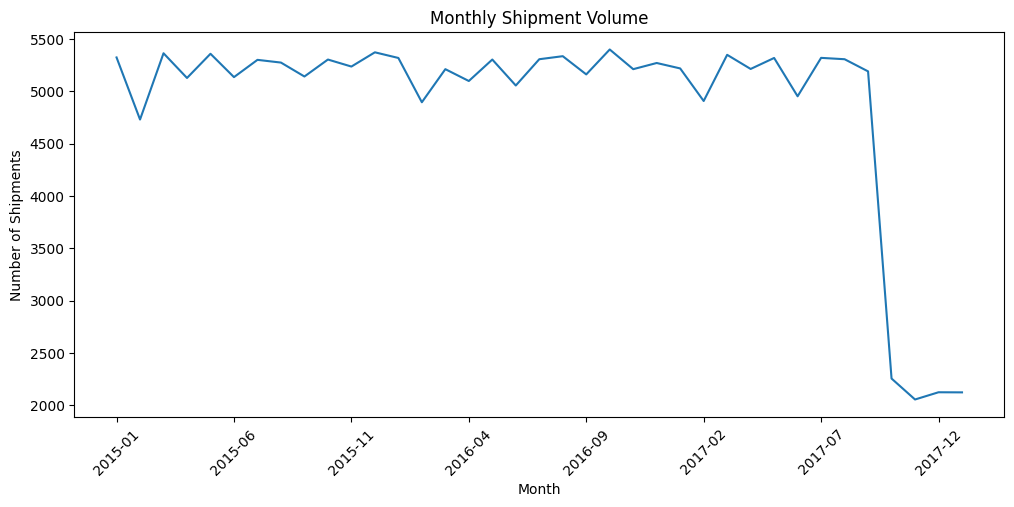

In [27]:
monthly_shipments.plot(
    figsize=(12, 5)
)

plt.title("Monthly Shipment Volume")
plt.xlabel("Month")
plt.ylabel("Number of Shipments")
plt.xticks(rotation=45)
plt.show()

In [28]:
monthly_delay = (
    df.groupby("order_month")["late_delivery_risk"]
    .mean() * 100
)

monthly_delay

order_month
2015-01    54.114994
2015-02    54.853034
2015-03    54.755688
2015-04    53.843153
2015-05    55.086802
2015-06    54.109856
2015-07    55.463295
2015-08    55.679879
2015-09    56.692607
2015-10    54.809506
2015-11    54.269341
2015-12    54.682554
2016-01    55.576453
2016-02    54.147936
2016-03    55.758157
2016-04    55.228566
2016-05    55.658242
2016-06    56.846063
2016-07    51.932139
2016-08    55.268091
2016-09    54.980620
2016-10    54.779548
2016-11    54.625720
2016-12    56.063769
2017-01    53.613188
2017-02    54.667754
2017-03    55.264634
2017-04    53.779739
2017-05    53.470002
2017-06    53.504343
2017-07    54.776232
2017-08    56.437323
2017-09    54.230102
2017-10    53.658537
2017-11    55.085158
2017-12    55.178908
2018-01    56.288271
Name: late_delivery_risk, dtype: float64

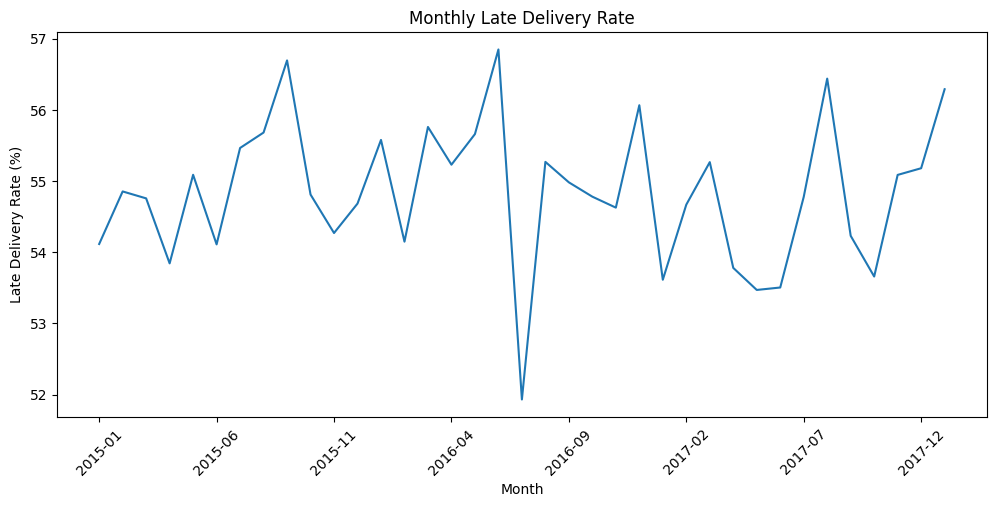

In [29]:
monthly_delay.plot(
    figsize=(12, 5)
)

plt.title("Monthly Late Delivery Rate")
plt.xlabel("Month")
plt.ylabel("Late Delivery Rate (%)")
plt.xticks(rotation=45)
plt.show()

In [30]:
delay_summary = (
    df["shipping_delay_days"]
    .value_counts()
    .sort_index()
    .to_frame("shipments")
)

delay_summary["percentage"] = (
    delay_summary["shipments"] / len(df) * 100
).round(2)

delay_summary

,shipments,percentage
shipping_delay_days,,
-2,21666,12.00
-1,21700,12.02
0,33753,18.70
1,60647,33.60
2,28718,15.91
3,7052,3.91
4,6983,3.87


In [31]:
shipping_mode_analysis = (
    df.groupby("shipping_mode")["late_delivery_risk"]
    .agg(["count", "sum"])
)

shipping_mode_analysis["delay_rate"] = (
    shipping_mode_analysis["sum"]
    / shipping_mode_analysis["count"]
    * 100
).round(2)

shipping_mode_analysis = shipping_mode_analysis.sort_values(
    "delay_rate",
    ascending=False
)

shipping_mode_analysis

,count,sum,delay_rate
shipping_mode,,,
First Class,27814,26513,95.32
Second Class,35216,26987,76.63
Same Day,9737,4454,45.74
Standard Class,107752,41023,38.07


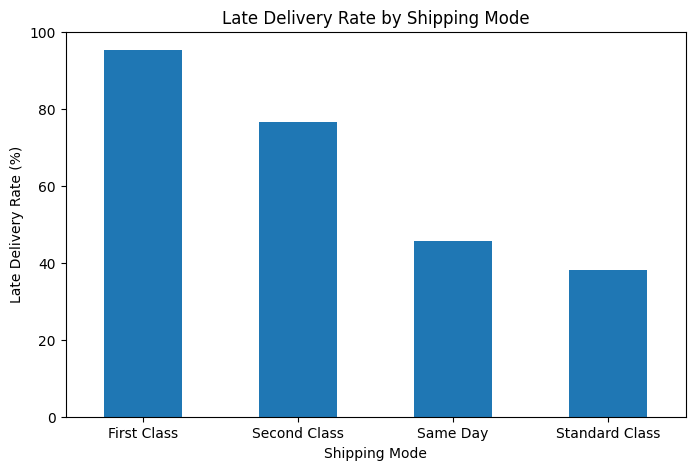

In [32]:
shipping_mode_analysis["delay_rate"].plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Late Delivery Rate by Shipping Mode")
plt.xlabel("Shipping Mode")
plt.ylabel("Late Delivery Rate (%)")
plt.xticks(rotation=0)
plt.show()